In [1]:
! pip install --upgrade -q pandas numpy scikit-learn imbalanced-learn xgboost

In [2]:
from collections import Counter

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import f1_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer

from xgboost import XGBClassifier

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

from utils.constants import *

In [3]:
df = pd.read_csv("../data/3_gold/dataset-processed-gb.csv")

categorical_features = list(CATEGORICAL_COLUMNS)

for col in categorical_features:
    df[col] = df[col].astype('category')

X = df.drop("class", axis=1)
y = df["class"]
y = y.map(TARGET_LABEL_MAP)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_RATIO, random_state=RANDOM_STATE, stratify=y
)

X_coarse = X_train.copy()
y_coarse = y_train.copy()
y_coarse = y_coarse.map(COARSE_LABEL_MAP)

high_risk_mask = y_train.isin([1, 2])
X_fine = X_train[high_risk_mask].copy()
y_fine = y_train[high_risk_mask].copy()
y_fine = y_fine.map(FINE_LABEL_MAP)

class_counts_coarse = Counter(y_coarse)
class_counts_fine = Counter(y_fine)

print("=== Coarse Data ===")
for class_idx, count in class_counts_coarse.items():
    print(f"Number of '{TARGET_NAMES_COARSE[class_idx]}' examples: {count}")

print("\n=== Fine Data ===")
for class_idx, count in class_counts_fine.items():
    print(f"Number of '{TARGET_NAMES_FINE[class_idx]}' examples: {count}")

=== Coarse Data ===
Number of 'high_risk' examples: 252418
Number of 'low_risk' examples: 359335

=== Fine Data ===
Number of 'alarm' examples: 228124
Number of 'severe' examples: 24294


In [12]:
ratio_coarse = class_counts_coarse[0] / class_counts_coarse[1]
ratio_fine = class_counts_fine[0] / class_counts_fine[1]

params_coarse = {
    'objective': 'binary:logistic',
    'eval_metric': 'aucpr',
    'enable_categorical': True,
    #'tree_method': 'hist',
    'scale_pos_weight': ratio_coarse,
    'random_state': RANDOM_STATE,
    'n_estimators': 3000,
    'early_stopping_rounds': 50,
    'max_depth': 4, 
    'learning_rate': 0.05,
    'subsample': 0.7,
    'colsample_bytree': 0.95,
    'reg_alpha': 8, 
    'reg_lambda': 12,
    'min_child_weight': 5, 
    'gamma': 5.0
}
params_fine = {
    'objective': 'binary:logistic',
    'eval_metric': 'aucpr',
    'enable_categorical': True,
    #'tree_method': 'hist',
    'scale_pos_weight': ratio_fine,
    'random_state': RANDOM_STATE,
    'n_estimators': 3000,
    'early_stopping_rounds': 50,
    'max_depth': 10, 
    'learning_rate': 0.03,
    'subsample': 0.7,
    'colsample_bytree': 0.95,
    'reg_alpha': 8, 
    'reg_lambda': 12,
    'min_child_weight': 5, 
    'gamma': 5.0
}

def get_xgb_models():
    model_coarse = XGBClassifier(**params_coarse)
    model_fine = XGBClassifier(**params_fine)
    return model_coarse, model_fine


def eval_hierarchical(
    model_coarse, model_fine, X_val, y_val, 
    threshold_coarse=0.35, threshold_fine=0.5
):
    # Predict Coarse (0 = Low, 1 = High)
    probs_coarse = model_coarse.predict_proba(X_val)[:, 1]
    
    preds_coarse = (probs_coarse >= threshold_coarse).astype(int)
    final_preds = preds_coarse.copy()
    
    high_risk_indices = np.where(preds_coarse == 1)[0]
    
    if len(high_risk_indices) > 0:
        X_high_risk = X_val.iloc[high_risk_indices]
        
        # Predict Fine (0 = Alarm, 1 = Severe)
        probs_fine_local = model_fine.predict_proba(X_high_risk)[:, 1]
        preds_fine_local = (probs_fine_local >= threshold_fine).astype(int)
        
        # Map Fine predictions back to Global labels
        preds_fine_global = np.array([FINE_LABEL_MAP_REVERSE[p] for p in preds_fine_local])
        final_preds[high_risk_indices] = preds_fine_global

    print(classification_report(y_val, final_preds, target_names=["Low Risk", "Alarm", "Severe"]))
    return f1_score(y_val, final_preds, average='macro'), final_preds


def train_hierarchical_xgb(X_coarse, y_coarse, X_fine, y_fine):
    X_train_coarse, X_val_coarse, y_train_coarse, y_val_coarse = train_test_split(
        X_coarse, y_coarse, test_size=TEST_RATIO, random_state=RANDOM_STATE, stratify=y_coarse
    )
    X_train_fine, X_val_fine, y_train_fine, y_val_fine = train_test_split(
        X_fine, y_fine, test_size=TEST_RATIO, random_state=RANDOM_STATE, stratify=y_fine
    )
    
    model_coarse, model_fine = get_xgb_models()
    
    print("Training Coarse Model...")
    model_coarse.fit(
        X_train_coarse, y_train_coarse,
        eval_set=[(X_val_coarse, y_val_coarse)]
    )

    print("Training Fine Model...")
    model_fine.fit(
        X_train_fine, y_train_fine,
        eval_set=[(X_val_fine, y_val_fine)] if len(X_val_fine) > 0 else None
    )
    
    return model_coarse, model_fine

In [13]:
model_coarse, model_fine = train_hierarchical_xgb(X_coarse, y_coarse, X_fine, y_fine)

f1, preds = eval_hierarchical(model_coarse, model_fine, X_test, y_test)

Training Coarse Model...
[0]	validation_0-aucpr:0.62299
[1]	validation_0-aucpr:0.64088
[2]	validation_0-aucpr:0.64832
[3]	validation_0-aucpr:0.65117
[4]	validation_0-aucpr:0.65718
[5]	validation_0-aucpr:0.66416
[6]	validation_0-aucpr:0.66890
[7]	validation_0-aucpr:0.67492
[8]	validation_0-aucpr:0.67291
[9]	validation_0-aucpr:0.67827
[10]	validation_0-aucpr:0.67782
[11]	validation_0-aucpr:0.67981
[12]	validation_0-aucpr:0.68064
[13]	validation_0-aucpr:0.68773
[14]	validation_0-aucpr:0.68863
[15]	validation_0-aucpr:0.69065
[16]	validation_0-aucpr:0.69240
[17]	validation_0-aucpr:0.69470
[18]	validation_0-aucpr:0.69496
[19]	validation_0-aucpr:0.69651
[20]	validation_0-aucpr:0.69860
[21]	validation_0-aucpr:0.69898
[22]	validation_0-aucpr:0.70047
[23]	validation_0-aucpr:0.70191
[24]	validation_0-aucpr:0.70392
[25]	validation_0-aucpr:0.70385
[26]	validation_0-aucpr:0.70559
[27]	validation_0-aucpr:0.70626
[28]	validation_0-aucpr:0.70712
[29]	validation_0-aucpr:0.70874
[30]	validation_0-aucpr:0

In [ ]:
! pip install matplotlib

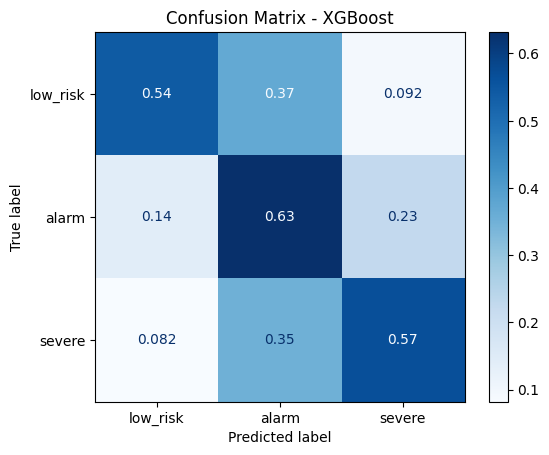

In [14]:
# Plot confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test, preds, display_labels=TARGET_NAMES, cmap=plt.cm.Blues, normalize='true'
)
plt.title("Confusion Matrix - XGBoost")
plt.show()